# Step1: Implementation of necesssary Libraries

In [1]:
import pandas as pd
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

2026-06-24 13:58:07.951166: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782309488.184430      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782309488.250925      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782309488.817524      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782309488.817585      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782309488.817588      23 computation_placer.cc:177] computation placer alr

# Step2:  Download and Load the Dataset

In [2]:
# Load the movies dataset
movies_df = pd.read_csv('/kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata/tmdb_5000_movies.csv')

# Load the credits dataset
credits_df = pd.read_csv('/kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata/tmdb_5000_credits.csv')
# Preview the first few rows of the movies dataset
movies_df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


# Step3: Data Preprocessing

In [3]:
import ast

# 1. Merge the two datasets on the movie ID
# 'id' in movies_df matches 'movie_id' in credits_df
credits_df = credits_df.rename(columns={'movie_id': 'id'})
df = pd.merge(movies_df, credits_df, on='id')

# 2. Clean JSON columns (convert stringified lists to readable python lists)
def convert_json_col(text):
    if pd.isna(text):
        return []
    # ast.literal_eval safely parses the string representation of lists/dicts
    return [item['name'] for item in ast.literal_eval(text)]

# Apply cleaning to genres and keywords
df['genres'] = df['genres'].apply(convert_json_col)
df['keywords'] = df['keywords'].apply(convert_json_col)

# 3. Handle Missing Values in numerical columns
df['runtime'] = df['runtime'].fillna(df['runtime'].mean())

# 4. Feature Selection for your Deep Learning model
# Let's say we want to predict 'vote_average' (Target) using numerical features
features = ['budget', 'popularity', 'revenue', 'runtime', 'vote_count']
X = df[features]
y = df['vote_average']

# 5. Split into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Scale the Numerical Features (crucial for Neural Networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training shape: {X_train_scaled.shape}")
print(f"Testing shape: {X_test_scaled.shape}")

Training shape: (3842, 5)
Testing shape: (961, 5)


# Step 4: Build the Neural Network Model

In [4]:
model = Sequential()

# Input layer & First hidden layer
# input_shape must match the number of features (5 in this case)
model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dropout(0.2)) # Dropout helps prevent the model from overfitting

# Second hidden layer
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

# Output layer 
# Since we are predicting a single continuous value (vote_average), we use 1 node with a 'linear' activation (default)
model.add(Dense(1, activation='linear'))

# Compile the model
# 'adam' is a great default optimizer, and Mean Squared Error (MSE) is standard for regression
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Display the model architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1782309503.954488      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782309503.960730      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

# Step 5: Training the Model:

In [5]:
# Set up Early Stopping
# 'patience=10' means if the validation loss doesn't improve for 10 epochs, it stops training
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train (fit) the model
print("Starting training...")
history = model.fit(
    X_train_scaled, 
    y_train,
    epochs=100,              # Maximum number of training cycles
    batch_size=32,           # How many samples to process at once
    validation_split=0.2,    # Set aside 20% of the training data to validate against
    callbacks=[early_stop],  # Attach the early stopping rule
    verbose=1                # Shows the progress bar
)
print("Training complete!")

Starting training...
Epoch 1/100


I0000 00:00:1782309506.486001      69 service.cc:152] XLA service 0x7dc8e800a640 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782309506.486044      69 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782309506.486048      69 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782309506.766772      69 cuda_dnn.cc:529] Loaded cuDNN version 91002


67/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 30.2077 - mae: 5.3346

I0000 00:00:1782309508.309957      69 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


97/97 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 19.6774 - mae: 3.9380 - val_loss: 6.2021 - val_mae: 1.9556
Epoch 2/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0663 - mae: 1.8604 - val_loss: 3.8285 - val_mae: 1.4660
Epoch 3/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.5915 - mae: 1.5191 - val_loss: 2.4341 - val_mae: 1.1534
Epoch 4/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.3674 - mae: 1.3126 - val_loss: 1.7241 - val_mae: 0.9840
Epoch 5/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.7706 - mae: 1.1869 - val_loss: 1.3827 - val_mae: 0.8883
Epoch 6/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.2932 - mae: 1.1243 - val_loss: 1.1523 - val_mae: 0.7758
Epoch 7/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.1880 - mae: 1.0843 - val_loss: 1.1526 - val_mae: 0.7992
Epoch 8/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.0353 - mae: 1.0539 - val_loss: 1.0300 - val_mae: 0.7267
Epoch 9/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.9821 - mae: 1

# Step 6: Evaluate and Visualize Model Performance

Evaluating on Test Data...
Test Mean Squared Error (Loss): 0.9868
Test Mean Absolute Error (MAE): 0.6447


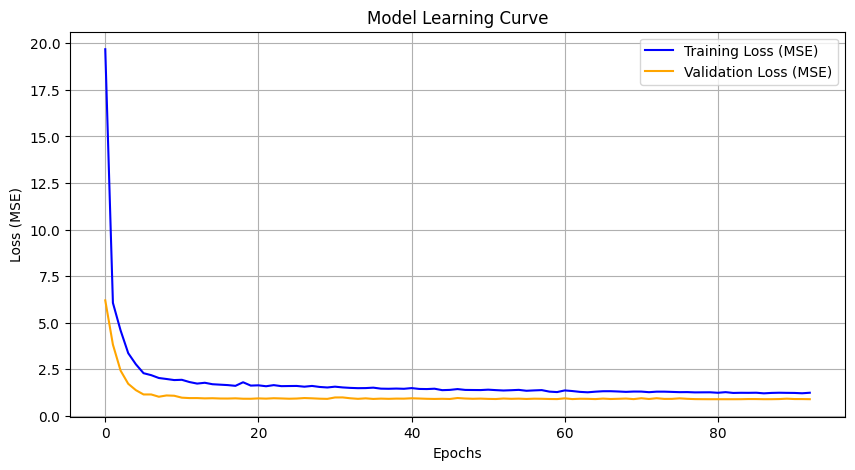

In [6]:
# 1. Evaluate the model on the unseen test set
print("Evaluating on Test Data...")
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Mean Squared Error (Loss): {test_loss:.4f}")
print(f"Test Mean Absolute Error (MAE): {test_mae:.4f}")

# 2. Plot the training vs. validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss (MSE)', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='orange')
plt.title('Model Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# Step 7: Make Predictions on Unseen Data

In [7]:
# Let's take the first 5 movies from our test set
samples_to_predict = X_test_scaled[:5]
actual_ratings = y_test[:5].values

# Generate predictions using the trained model
print("Generating predictions...\n")
predicted_ratings = model.predict(samples_to_predict)

# Print a side-by-side comparison
print("Model Predictions vs Actual Ratings:")
print("-" * 45)
for i in range(5):
    predicted = predicted_ratings[i][0]
    actual = actual_ratings[i]
    difference = abs(predicted - actual)
    print(f"Predicted: {predicted:.2f} | Actual: {actual:.2f} | Off by: {difference:.2f}")

Generating predictions...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
Model Predictions vs Actual Ratings:
---------------------------------------------
Predicted: 5.36 | Actual: 5.20 | Off by: 0.16
Predicted: 5.74 | Actual: 5.70 | Off by: 0.04
Predicted: 5.50 | Actual: 5.50 | Off by: 0.00
Predicted: 6.40 | Actual: 6.70 | Off by: 0.30
Predicted: 6.99 | Actual: 7.40 | Off by: 0.41


In [8]:
import tensorflow as tf

# 1. Save the standard Keras model for future use in Python/Web environments
model.save('movie_rating_predictor.keras')
print("Standard model saved as 'movie_rating_predictor.keras'")

# 2. Export to TensorFlow Lite for mobile application integration
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('movie_rating_predictor.tflite', 'wb') as f:
    f.write(tflite_model)
print("Mobile-optimized model saved as 'movie_rating_predictor.tflite'")

Standard model saved as 'movie_rating_predictor.keras'
INFO:tensorflow:Assets written to: /tmp/tmp7q4dmh_6/assets


INFO:tensorflow:Assets written to: /tmp/tmp7q4dmh_6/assets


Saved artifact at '/tmp/tmp7q4dmh_6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 5), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  138305540822736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138305540825808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138305540824656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138305540825232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138305540827152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138305540828112: TensorSpec(shape=(), dtype=tf.resource, name=None)
Mobile-optimized model saved as 'movie_rating_predictor.tflite'


W0000 00:00:1782309547.106007      23 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1782309547.106043      23 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1782309547.112527      23 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


In [9]:
import joblib

# Export the scaler object
joblib.dump(scaler, 'scaler.pkl')
print("Scaler saved as 'scaler.pkl'")

Scaler saved as 'scaler.pkl'
